# Zeta Distribution

`Zeta(shape)` is a discrete power-law distribution on the whole numbers `1, 2, 3, ...`, with each value's probability proportional to `1 / k ** shape`:

$$P(X = k) = \frac{1}{k^{\text{shape}} \, \zeta(\text{shape})}$$

The constant on the bottom is the Riemann zeta function, which is just whatever number makes the probabilities add up to 1 -- and it is where the distribution gets its name.

It models situations where a few outcomes are enormously more common than everything else: word frequencies in a language, city populations, citation counts. It is the unbounded version of `Zipf` -- where a `Zipf` ranks a fixed list of `n` items, a `Zeta` lets the list run on forever.

`shape` must be **greater than 1**; at 1 or below the probabilities cannot be normalized.

In [1]:
from symbulate import *

## Draw a value from a zeta distribution

Most draws come out as 1 -- with `shape = 2.5`, about 75% of them do.

In [2]:
Zeta(shape=2.5).draw()

1

## The probabilities fall off as a power of `k`

Each value is less likely than the one before, and the drop is steep.

In [3]:
X = Zeta(shape=2.5)
[round(float(X.pmf(k)), 5) for k in range(1, 11)]

[0.74544,
 0.13178,
 0.04782,
 0.0233,
 0.01333,
 0.00845,
 0.00575,
 0.00412,
 0.00307,
 0.00236]

## Whether the mean and variance even exist depends on `shape`

This is the most important thing to know about the zeta distribution. Its tail is heavy enough that the usual summaries can simply fail to exist:

- the **mean** is finite only when `shape > 2`
- the **variance** is finite only when `shape > 3`

Outside those ranges Symbulate reports `inf` rather than a number, which is the honest answer -- the defining sums diverge.

In [4]:
for s in [1.5, 2.5, 3.5]:
    print("shape =", s, "  mean =", float(Zeta(shape=s).mean()), "  var =", float(Zeta(shape=s).var()))

shape = 1.5   mean = inf   var = inf
shape = 2.5   mean = 1.947372466316956   var = inf
shape = 3.5   mean = 1.1905981493617699   var = 0.9010141012513622


## Plot the pmf

A dot at each whole number, joined by a dashed line. The default window shows the first 20 values, which is where the shape is visible -- the support itself carries on forever.

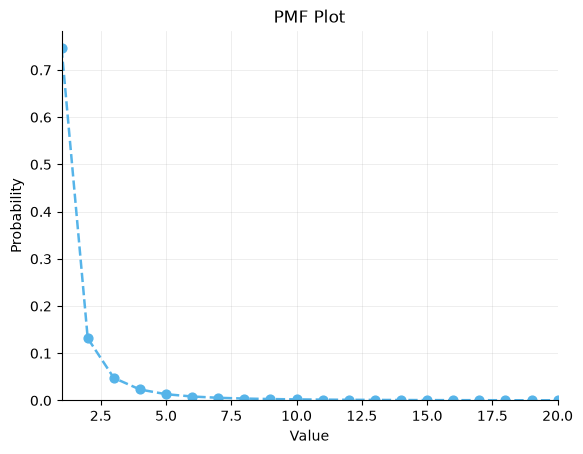

In [5]:
Zeta(shape=2.5).plot()

## Plot the CDF

A step function that shoots up almost all the way at the very first step, then creeps.

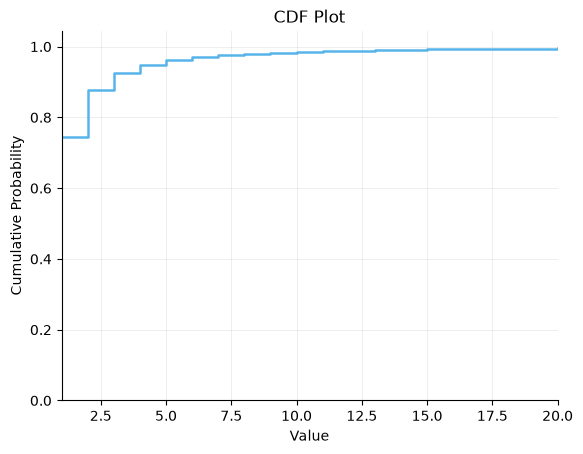

In [6]:
Zeta(shape=2.5).plot(cdf=True)

## A larger shape piles more probability onto 1

Because the decay is so steep, the interesting differences all live in the first few values, so this zooms in on them.

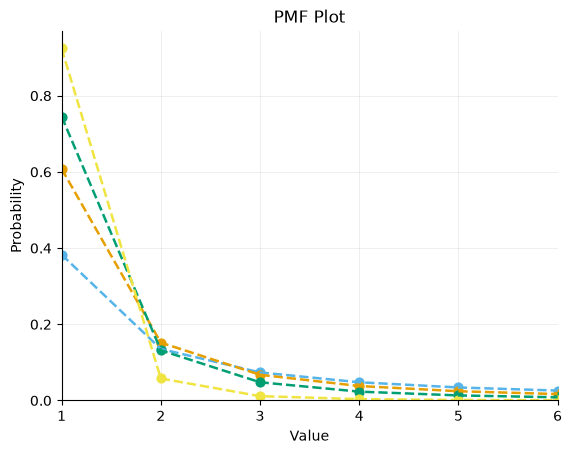

In [7]:
for s in [1.5, 2.0, 2.5, 4.0]:
    Zeta(shape=s).plot()
xlim(1, 6);

In [8]:
[round(float(Zeta(shape=s).pmf(1)), 4) for s in [1.5, 2.0, 2.5, 4.0]]

[0.3828, 0.6079, 0.7454, 0.9239]

## Assign and simulate a random variable

A frequency table shows the power law directly: a huge pile on 1, then a long thin tail. Look at the largest value in the table -- a single draw can land absurdly far out.

In [9]:
Z = RV(Zeta(shape=2.5))
sims = Z.sim(10000)
sims.tabulate()

1,7457
2,1303
3,465
4,250
5,135
6,87
7,54
8,49
9,32
10,19
11,23


## The heavy tail defeats the automatic plot

Plotting the simulated values directly gives something unreadable. A handful of draws land enormously far out, so the axis has to stretch all the way to cover them, and every bit of real structure gets squashed against the left edge.

Look at the horizontal axis -- and note that how far it reaches changes a lot from run to run, since it is set by the single largest draw.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


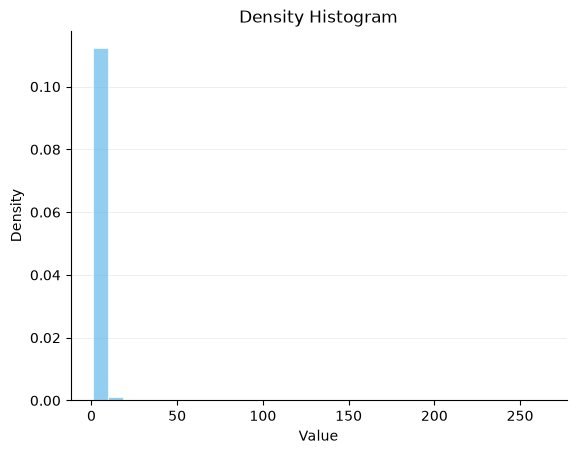

In [10]:
sims.plot()

Trimming the axis fixes it, and the simulated stems then sit right under the theoretical pmf.

Asking for `type="impulse"` explicitly is worth doing too. With this much spread, the sample sometimes contains more distinct values than Symbulate treats as discrete, and in that case it would bin them into a histogram instead of drawing one stem per value -- so which plot you get would otherwise depend on the luck of the sample.

(`xlim(0, 12)` comes last because it has to undo the stretching, and it starts at 0 rather than 1 so the tall stem on the value 1 is not clipped against the axis; the `;` just hides the pair of limits it returns.)

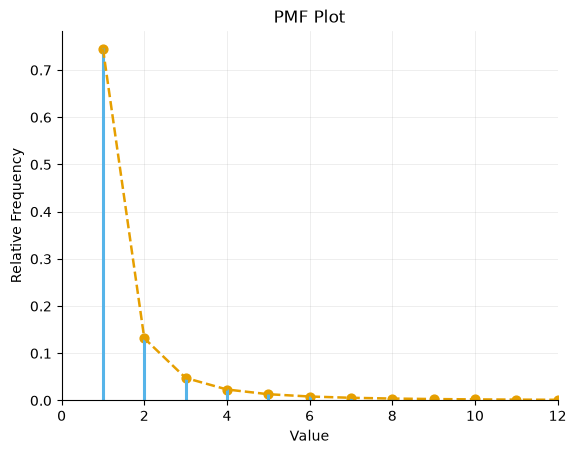

In [11]:
sims.plot(type="impulse")
Zeta(shape=2.5).plot()
xlim(0, 12);

## Relationship: the zeta is a Zipf with no upper limit

A `Zipf(shape, n)` spreads the same power law over a fixed list of `n` ranks. Let `n` grow and it turns into the `Zeta`. Below, the short curves are `Zipf` with `n = 3` and `n = 5`: each stops at its own last rank and sits slightly higher, because the probability that would have gone to the missing tail has to be shared among fewer values.

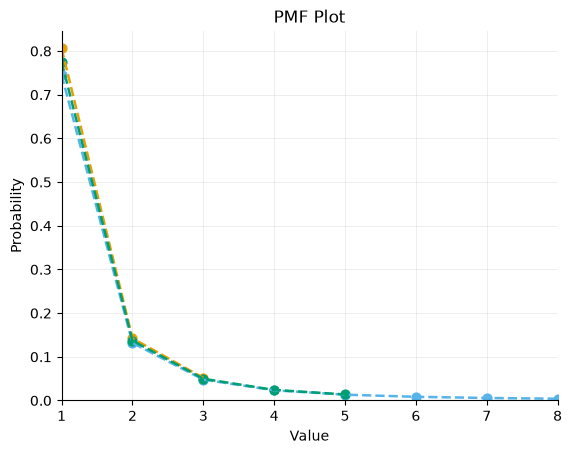

In [12]:
Zeta(shape=2.5).plot()
Zipf(shape=2.5, n=3).plot()
Zipf(shape=2.5, n=5).plot()
xlim(1, 8);

The convergence is easier to see in numbers. Here is `P(X = 1)` for a growing `n`, with the zeta's value last:

In [13]:
for n in [3, 5, 10, 100, 10000]:
    print("Zipf(n = %-6d) P(X = 1) = %.6f" % (n, Zipf(shape=2.5, n=n).pmf(1)))
print("Zeta            P(X = 1) = %.6f" % Zeta(shape=2.5).pmf(1))

Zipf(n = 3     ) P(X = 1) = 0.805849
Zipf(n = 5     ) P(X = 1) = 0.775155
Zipf(n = 10    ) P(X = 1) = 0.756475
Zipf(n = 100   ) P(X = 1) = 0.745809
Zipf(n = 10000 ) P(X = 1) = 0.745442
Zeta            P(X = 1) = 0.745441


## A warning about scipy's names

If you go looking for these in scipy, the names are swapped from what you would guess:

- `scipy.stats.zipf` is **this** distribution, the zeta
- `scipy.stats.zipfian` is the finite-list Zipf, which Symbulate exposes as `Zipf`

Symbulate's `Zeta` and `Zipf` are named for what they actually are, so you should not have to think about this -- but it is worth knowing if you ever compare results against scipy directly.